<a href="https://colab.research.google.com/github/zappolag/python-data-cleaning-pipeline/blob/main/sales_cleaning_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Python is working
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB


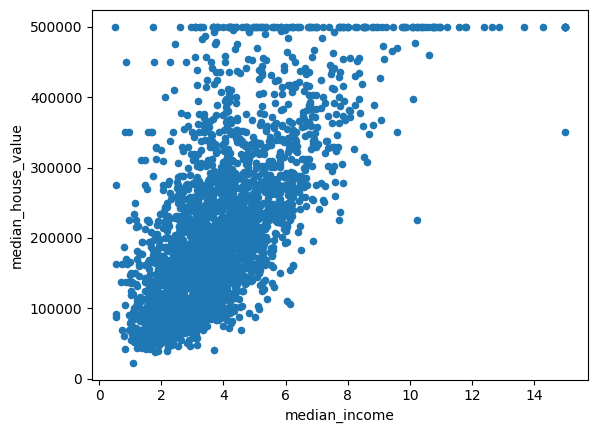

In [18]:
import pandas as pd
import numpy as np

print("Python is working")

df=pd.read_csv("/content/sample_data/california_housing_test.csv")
df.head()
df.shape
df.info()
df.isna().sum()
#remove duplicates
df=df.drop_duplicates()
df["rooms_per_household"] = (
    df["total_rooms"] / df["households"]
)
#new variables
df["people_per_household"] = (
    df["population"] / df["households"]
)
df["bedroom_ratio"] = (
    df["total_bedrooms"] / df["total_rooms"]
)
#average home value
df["median_house_value"].mean()
#highest income areas
df.sort_values(
    "median_income",
    ascending=False
).head(10)

#Does income relate to house value
df[["median_income","median_house_value"]].corr()
df.plot(
    x="median_income",
    y="median_house_value",
    kind="scatter"
)
#export
df.to_csv(
    "clean_california_housing.csv",
    index=False
)